# T-SNE to visualize high-dimensional data sets

In [5]:
from __future__ import print_function
import time

import numpy as np 
import pandas as pd 

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import seaborn as sns




In [18]:
mnist = fetch_openml('mnist_784')

x = mnist.data / 255.0
y = mnist.target

print(x.shape, y.shape)



(70000, 784) (70000,)


## Converting matrix and vector to pandas DataFrame 

In [19]:
feat_cols = ['pixel'+str(i) for i in range(x.shape[1]) ]

df = pd.DataFrame(x, columns=feat_cols)
df['y'] = y
df['label'] = df['y'].apply(lambda i: str(i))

x, y = None, None

print('Size of the dataframe: {}'.format(df.shape))

Size of the dataframe: (70000, 786)


## Reproducability of the results

In [20]:
# chooses a random amount of digits for the subset. Important as dataset is sorted by its label (we also dont want to use 70k digits). So we create random permutation
np.random.seed(42)

rndperm = np.random.permutation(df.shape[0])


## generating 30 plots of random selected images

<Figure size 640x480 with 0 Axes>

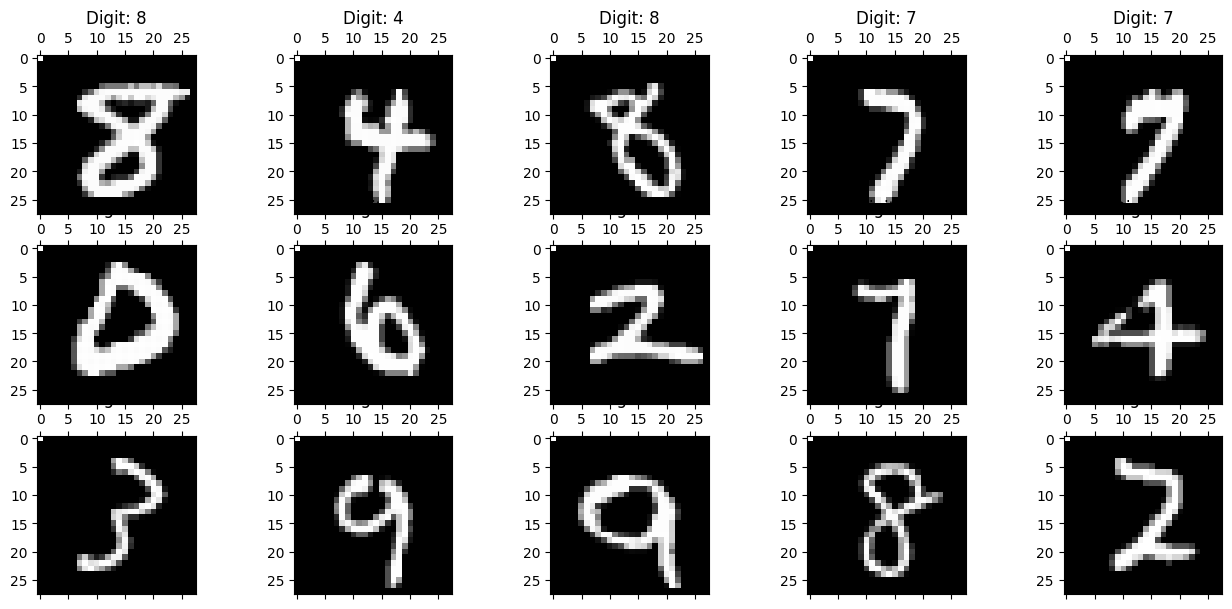

In [21]:
plt.gray()
fig = plt.figure( figsize=(16,7) )
for i in range(0,15):
    ax = fig.add_subplot(3,5,i+1, title="Digit: {}".format(str(df.loc[rndperm[i], 'label'])) )
    
    ax.matshow(df.loc[rndperm[i],feat_cols].values.reshape((28,28)).astype(float))
plt.show()

# Applying Principle Component Analysis (PCA)

In [24]:
# PCA is a technique used to reduce amount of dimensions in a dataset while retaining information

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
df_imputed = imputer.fit_transform(df[feat_cols])

pca = PCA(n_components = 3)
pca_result = pca.fit_transform(df_imputed)

df['pca-one'] = pca_result[:,0]
df['pca-two'] = pca_result[:,1]
df['pca-three'] = pca_result[:,2]

print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))


c:\Users\maxna\Documents\Projects\Machine Learning Algorithms\.venv\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['pixel0']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Explained variation per principal component: [0.09746116 0.07155445 0.06149531]


## creating the scatterplot

<Axes: xlabel='pca-one', ylabel='pca-two'>

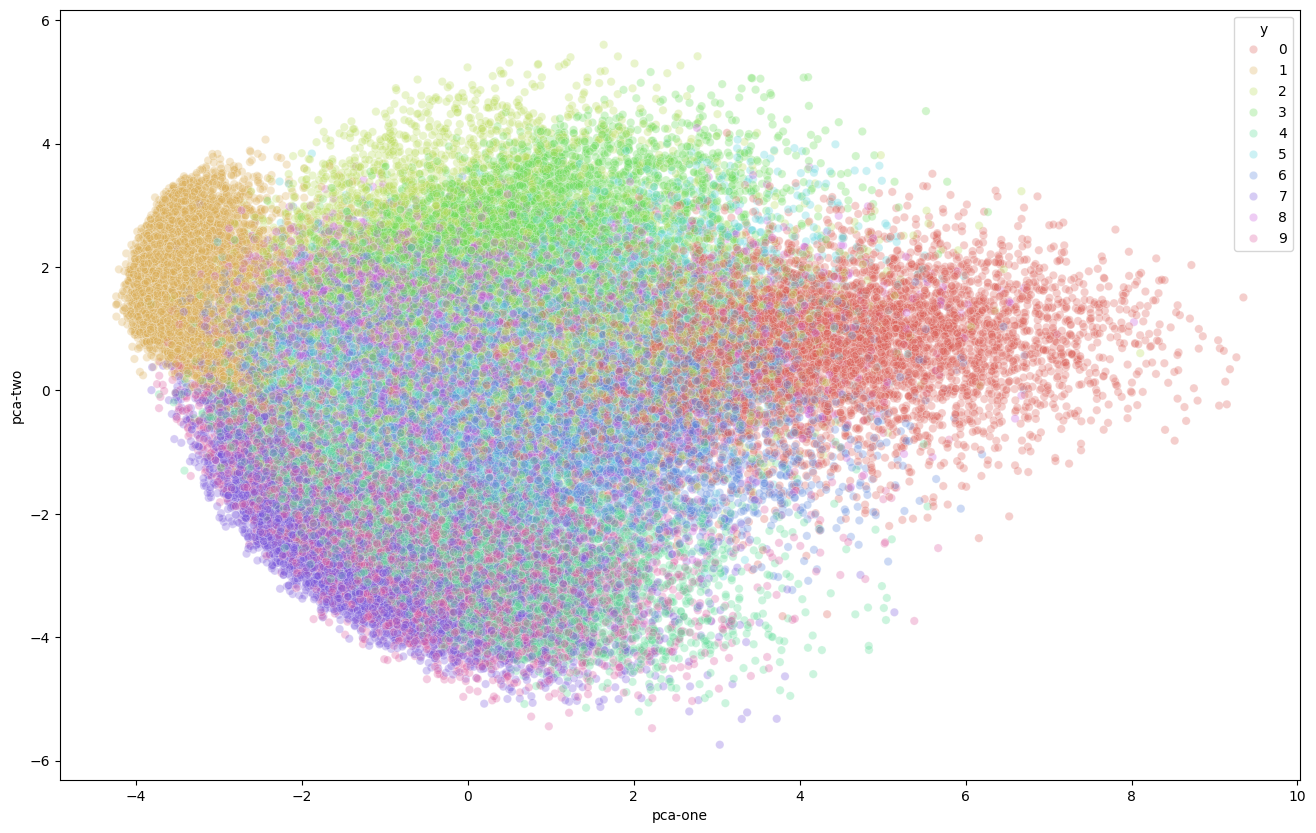

In [ ]:
# scatteplot is made to visually represent first and second principal component with colours
plt.figure(figsize=(16,10))

sns.scatterplot(
    x="pca-one",
    y="pca-two",
    hue="y",
    palette=sns.color_palette('hls', 10),
    data=df.loc[rndperm,:],
    legend="full",
    alpha=0.3
)

## Visualizing a 3-Dimensional version

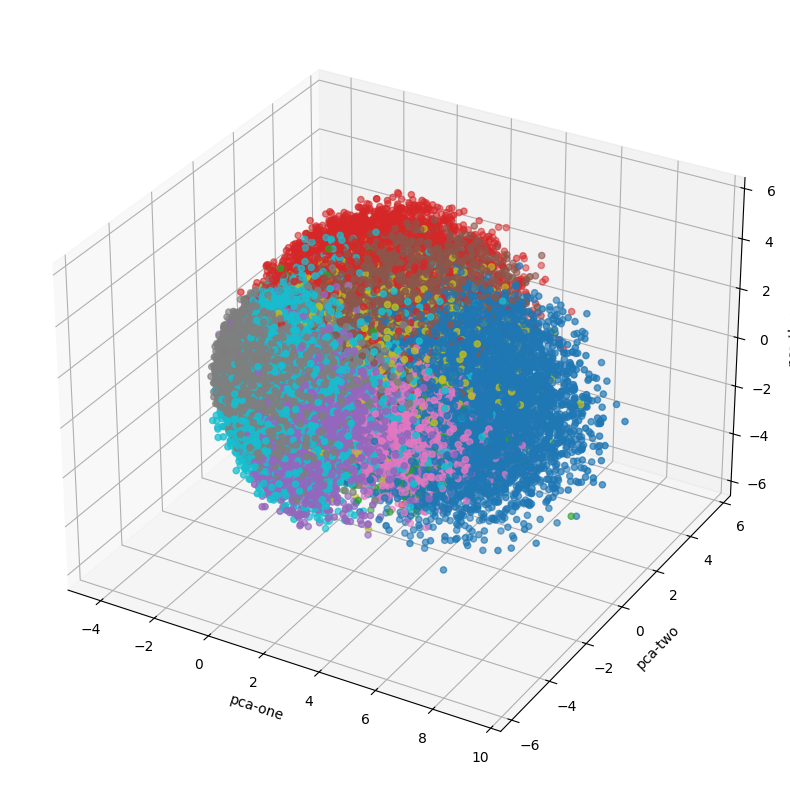

In [ ]:
# to further refine the data, T-SNE helps us reduce number of dimensions for visualizing the data


fig = plt.figure(figsize=(16,10)) 
ax = fig.add_subplot(projection='3d')

ax.scatter(
    xs=df.loc[rndperm,:]["pca-one"],
    ys=df.loc[rndperm,:]["pca-two"],
    zs=df.loc[rndperm,:]["pca-three"],
    
    # ensures c is a numberic value
    c=df.loc[rndperm, "y"].astype(float),
    cmap = 'tab10'
)
ax.set_xlabel('pca-one')
ax.set_ylabel('pca-two')
ax.set_zlabel('pca-three')

plt.show()